In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt




In [2]:
path = 'household_power_consumption.txt'
df = pd.read_csv(path, sep=';', na_values='?', low_memory=False)
print(f'Data shape: {df.shape}')
print(f'\nFirst few rows:')
print(df.head())
print(f'\nColumn names: {df.columns.tolist()}')
print(f'\nData types:\n{df.dtypes}')
print(f'\nMissing values:\n{df.isna().sum()}')

Data shape: (2075259, 9)

First few rows:
         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00                4.216                  0.418   234.84   
1  16/12/2006  17:25:00                5.360                  0.436   233.63   
2  16/12/2006  17:26:00                5.374                  0.498   233.29   
3  16/12/2006  17:27:00                5.388                  0.502   233.74   
4  16/12/2006  17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  

Column names: ['Date', 'Time', 'Global_active_power', 'G

In [3]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


In [5]:
df['Global_active_power'].isnull()

0          False
1          False
2          False
3          False
4          False
           ...  
2075254    False
2075255    False
2075256    False
2075257    False
2075258    False
Name: Global_active_power, Length: 2075259, dtype: bool

In [14]:
for j in range(1,7):
       print(df.iloc[:, j].unique())

['17:24:00' '17:25:00' '17:26:00' ... '17:21:00' '17:22:00' '17:23:00']
[4.216 5.36  5.374 ... 9.63  9.648 8.6  ]
[0.418 0.436 0.498 0.502 0.528 0.522 0.52  0.51  0.47  0.478 0.398 0.422
 0.282 0.152 0.156 0.    0.076 0.09  0.2   0.058 0.18  0.144 0.118 0.108
 0.202 0.192 0.186 0.116 0.136 0.148 0.16  0.158 0.1   0.082 0.05  0.052
 0.162 0.086 0.048 0.054 0.068 0.166 0.174 0.178 0.188 0.088 0.08  0.07
 0.084 0.074 0.106 0.092 0.064 0.046 0.138 0.134 0.132 0.12  0.13  0.154
 0.078 0.142 0.14  0.146 0.15  0.17  0.102 0.072 0.06  0.056 0.062 0.112
 0.066 0.172 0.168 0.194 0.184 0.096 0.164 0.182 0.094 0.098 0.176 0.19
 0.204 0.22  0.198 0.208 0.244 0.334 0.298 0.296 0.286 0.278 0.104 0.258
 0.238 0.256 0.214 0.23  0.21  0.24  0.124 0.122 0.27  0.302 0.272 0.25
 0.294 0.3   0.128 0.126 0.234 0.242 0.316 0.28  0.288 0.224 0.11  0.248
 0.254 0.222 0.246 0.216 0.212 0.114 0.206 0.228 0.226 0.196 0.218 0.368
 0.338 0.31  0.304 0.292 0.268 0.266 0.26  0.396 0.38  0.4   0.384 0.416
 0.404 0.382 

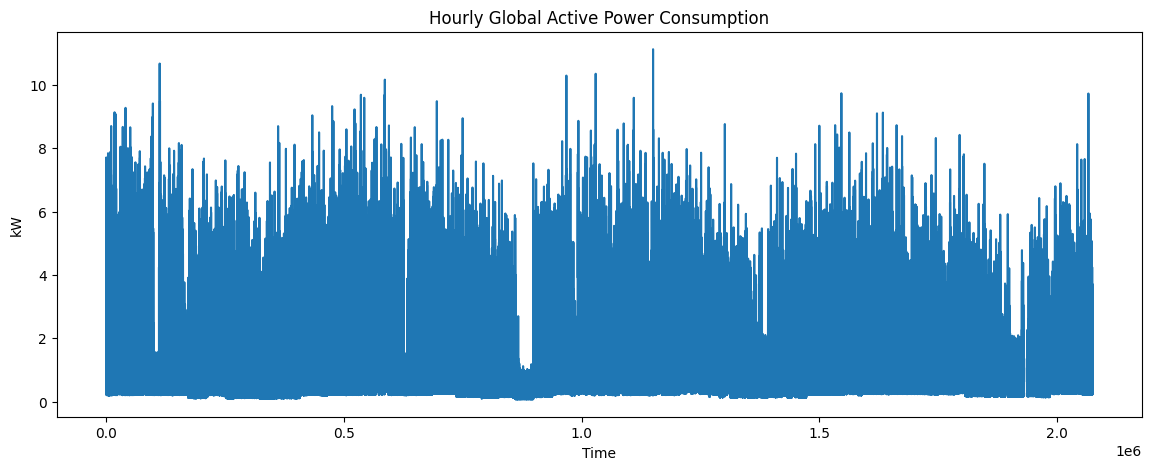

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(df.index, df['Global_active_power'])
plt.title("Hourly Global Active Power Consumption")
plt.xlabel("Time")
plt.ylabel("kW")
plt.show()


In [7]:
df.isna().sum()


Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [9]:
df['datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

df = df.set_index('datetime')
df = df.sort_index()


In [10]:
df = df.drop(columns=['Date', 'Time'])


In [12]:
df['Global_active_power'] = df['Global_active_power'].interpolate(method='time')


In [13]:
print(df.index)
print(df.index.is_monotonic_increasing)
print(df.index.inferred_freq)


DatetimeIndex(['2006-12-16 17:24:00', '2006-12-16 17:25:00',
               '2006-12-16 17:26:00', '2006-12-16 17:27:00',
               '2006-12-16 17:28:00', '2006-12-16 17:29:00',
               '2006-12-16 17:30:00', '2006-12-16 17:31:00',
               '2006-12-16 17:32:00', '2006-12-16 17:33:00',
               ...
               '2010-11-26 20:53:00', '2010-11-26 20:54:00',
               '2010-11-26 20:55:00', '2010-11-26 20:56:00',
               '2010-11-26 20:57:00', '2010-11-26 20:58:00',
               '2010-11-26 20:59:00', '2010-11-26 21:00:00',
               '2010-11-26 21:01:00', '2010-11-26 21:02:00'],
              dtype='datetime64[ns]', name='datetime', length=2075259, freq=None)
True
min


In [14]:
df = df.asfreq('H')


/var/folders/vs/xrc085j14w14j6lp_v8gyj8w0000gn/T/ipykernel_21203/1092682339.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.asfreq('H')


In [15]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Global_active_power'])
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")


ADF Statistic: -14.822967258785031
p-value: 1.950904699167383e-27


In [16]:
df['gap_diff'] = df['Global_active_power'].diff().dropna()


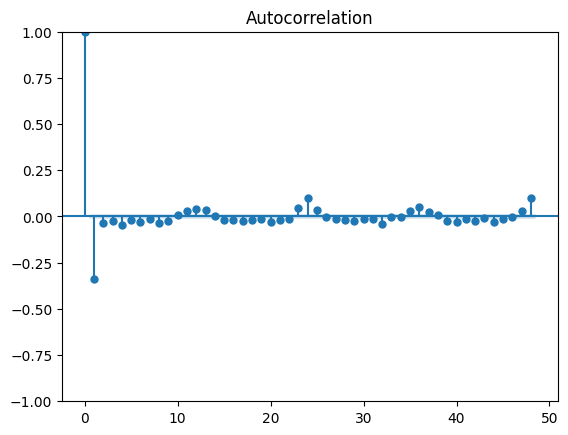

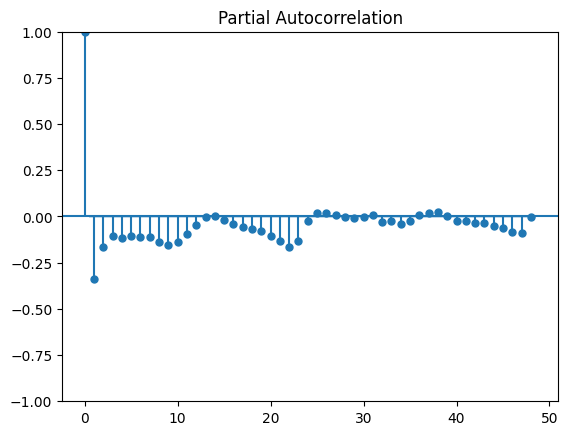

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['gap_diff'].dropna(), lags=48)
plot_pacf(df['gap_diff'].dropna(), lags=48)
plt.show()


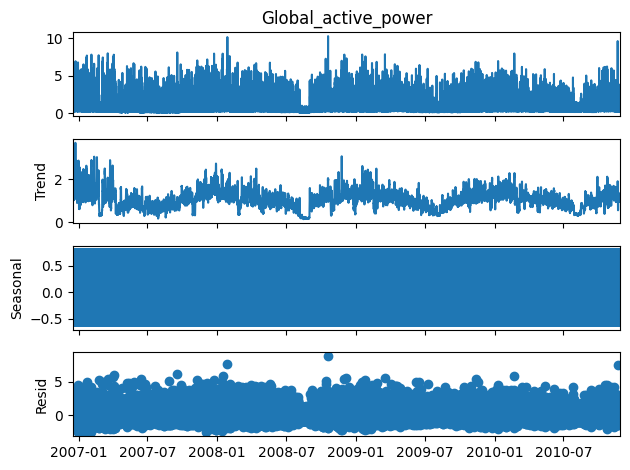

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(
    df['Global_active_power'],
    model='additive',
    period=24
)
decomp.plot()
plt.show()


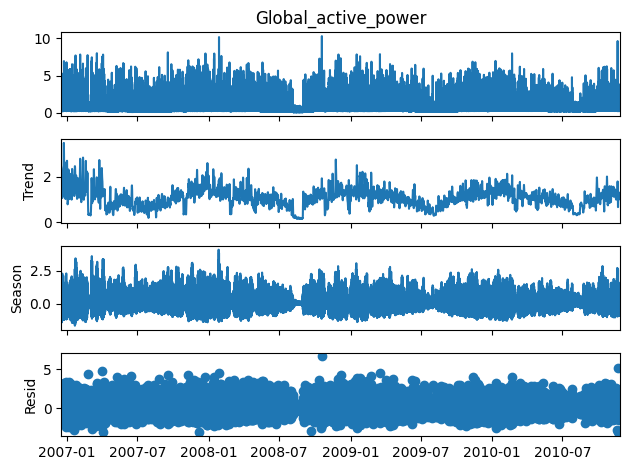

In [19]:
from statsmodels.tsa.seasonal import STL

stl = STL(df['Global_active_power'], period=24)
res = stl.fit()
res.plot()
plt.show()


In [27]:
horizon = 168

train = df.iloc[:-horizon]
test  = df.iloc[-horizon:]

y_true = test['Global_active_power']


In [30]:
sarima_model = SARIMAX(
    train['Global_active_power'],
    order=(1,1,1),
    seasonal_order=(1,1,1,24)
)
sarima_fit = sarima_model.fit(disp=False)

sarima_forecast = sarima_fit.forecast(steps=horizon)

y_pred_sarima = sarima_forecast


/opt/miniconda3/envs/yo/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/yo/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/yo/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


In [31]:
sarima_fit.aic, sarima_fit.bic


(np.float64(84881.15649136424), np.float64(84923.38482378404))

In [22]:
%pip install prophet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 5.7 MB/s  0:00:02 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 2.0 MB/s  0:00:00m 6.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [prophet]━━━ 3/4 [prophet]y]
Note: you may need to restart the kernel to use updated packages.


In [32]:
from prophet import Prophet
prophet_train = train.reset_index()[['datetime', 'Global_active_power']]
prophet_train.columns = ['ds', 'y']

m = Prophet(daily_seasonality=True, weekly_seasonality=True)
m.fit(prophet_train)

future = m.make_future_dataframe(periods=horizon, freq='H')
forecast = m.predict(future)

prophet_forecast = forecast.tail(horizon)['yhat'].values

y_pred_prophet = prophet_forecast


17:17:27 - cmdstanpy - INFO - Chain [1] start processing
17:17:31 - cmdstanpy - INFO - Chain [1] done processing
/opt/miniconda3/envs/yo/lib/python3.12/site-packages/prophet/forecaster.py:1872: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(
/opt/miniconda3/envs/yo/lib/python3.12/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/opt/miniconda3/envs/yo/lib/python3.12/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/opt/miniconda3/envs/yo/lib/python3.12/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/opt/miniconda3/envs/yo/lib/python3.12/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_

In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse_sarima = np.sqrt(mean_squared_error(y_true, y_pred_sarima))
mae_sarima  = mean_absolute_error(y_true, y_pred_sarima)


In [34]:
rmse_prophet = np.sqrt(mean_squared_error(y_true, y_pred_prophet))
mae_prophet  = mean_absolute_error(y_true, y_pred_prophet)


In [35]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet'],
    'RMSE': [rmse_sarima, rmse_prophet],
    'MAE':  [mae_sarima, mae_prophet]
})

print(results)


     Model      RMSE       MAE
0   SARIMA  0.965885  0.606789
1  Prophet  1.016265  0.722288


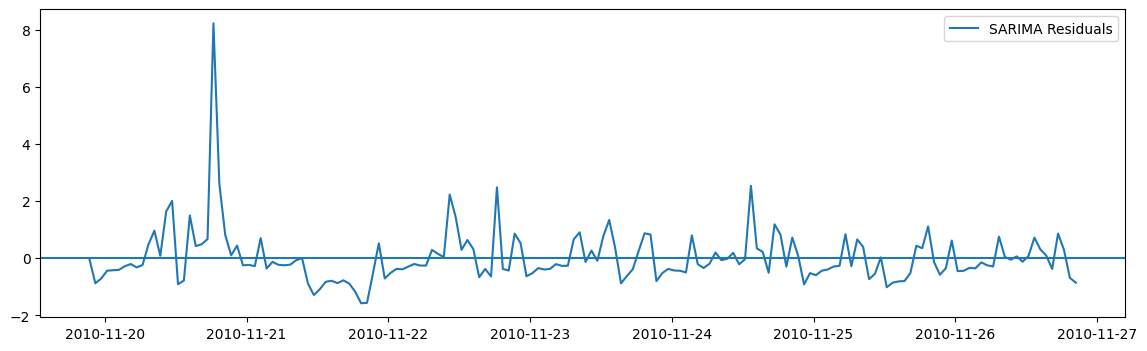

In [36]:
sarima_resid = y_true - y_pred_sarima
prophet_resid = y_true.values - y_pred_prophet
plt.figure(figsize=(14,4))
plt.plot(test.index, sarima_resid, label='SARIMA Residuals')
plt.axhline(0)
plt.legend()
plt.show()



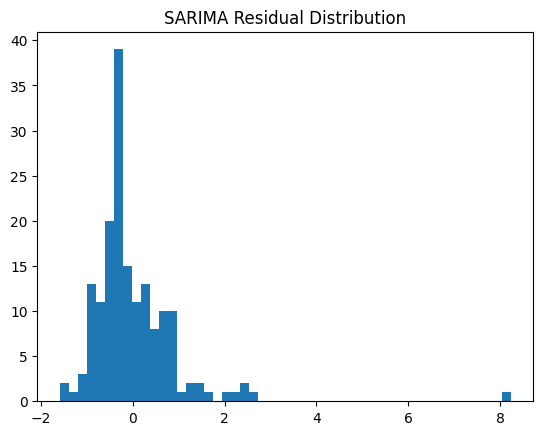

In [37]:
plt.hist(sarima_resid, bins=50)
plt.title("SARIMA Residual Distribution")
plt.show()


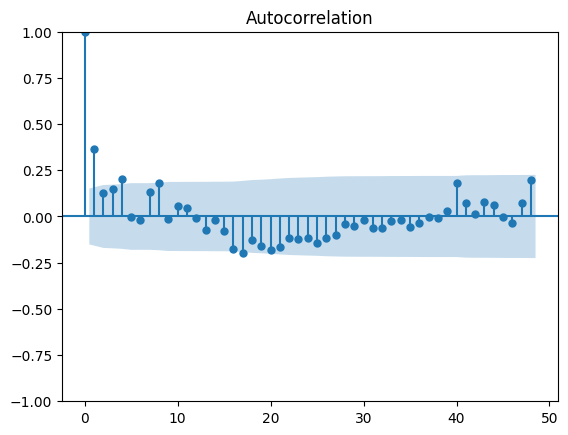

In [38]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(sarima_resid, lags=48)
plt.show()


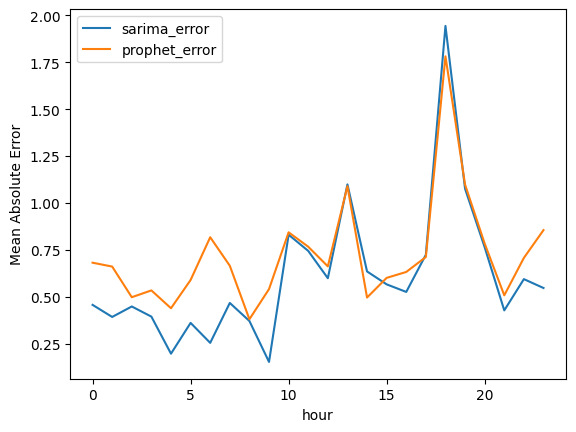

In [39]:
error_df = pd.DataFrame({
    'hour': test.index.hour,
    'sarima_error': abs(sarima_resid),
    'prophet_error': abs(prophet_resid)
})

error_df.groupby('hour').mean().plot()
plt.ylabel("Mean Absolute Error")
plt.show()


In [40]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.01, random_state=42)
df['anomaly'] = iso.fit_predict(df[['Global_active_power']]) == -1


In [41]:
df_clean = df.copy()
df_clean.loc[df_clean['anomaly'], 'Global_active_power'] = np.nan
df_clean['Global_active_power'] = df_clean['Global_active_power'].interpolate(method='time')


In [42]:
train_clean = df_clean.iloc[:-horizon]
test_clean  = df_clean.iloc[-horizon:]

y_true_clean = test_clean['Global_active_power']


In [43]:
sarima_clean = SARIMAX(
    train_clean['Global_active_power'],
    order=(1,1,1),
    seasonal_order=(1,1,1,24)
).fit(disp=False)

y_pred_sarima_clean = sarima_clean.forecast(steps=horizon)


/opt/miniconda3/envs/yo/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/yo/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/yo/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


In [44]:
prophet_train_clean = train_clean.reset_index()[['datetime', 'Global_active_power']]
prophet_train_clean.columns = ['ds', 'y']

m_clean = Prophet(daily_seasonality=True, weekly_seasonality=True)
m_clean.fit(prophet_train_clean)

future_clean = m_clean.make_future_dataframe(periods=horizon, freq='H')
forecast_clean = m_clean.predict(future_clean)

y_pred_prophet_clean = forecast_clean.tail(horizon)['yhat'].values


17:21:18 - cmdstanpy - INFO - Chain [1] start processing
17:21:21 - cmdstanpy - INFO - Chain [1] done processing
/opt/miniconda3/envs/yo/lib/python3.12/site-packages/prophet/forecaster.py:1872: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(
/opt/miniconda3/envs/yo/lib/python3.12/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/opt/miniconda3/envs/yo/lib/python3.12/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/opt/miniconda3/envs/yo/lib/python3.12/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/opt/miniconda3/envs/yo/lib/python3.12/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_

In [45]:
rmse_sarima_clean = np.sqrt(mean_squared_error(y_true_clean, y_pred_sarima_clean))
mae_sarima_clean  = mean_absolute_error(y_true_clean, y_pred_sarima_clean)

rmse_prophet_clean = np.sqrt(mean_squared_error(y_true_clean, y_pred_prophet_clean))
mae_prophet_clean  = mean_absolute_error(y_true_clean, y_pred_prophet_clean)


In [46]:
results = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet'],
    'RMSE (Before)': [rmse_sarima, rmse_prophet],
    'RMSE (After)':  [rmse_sarima_clean, rmse_prophet_clean],
    'MAE (Before)':  [mae_sarima, mae_prophet],
    'MAE (After)':   [mae_sarima_clean, mae_prophet_clean]
})

print(results)


     Model  RMSE (Before)  RMSE (After)  MAE (Before)  MAE (After)
0   SARIMA       0.965885      0.744424      0.606789     0.572193
1  Prophet       1.016265      0.809521      0.722288     0.669174


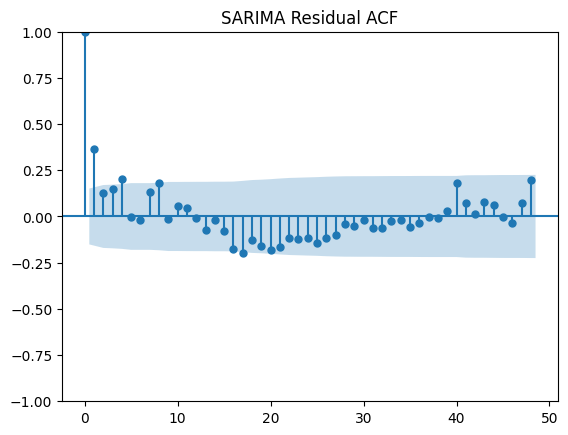

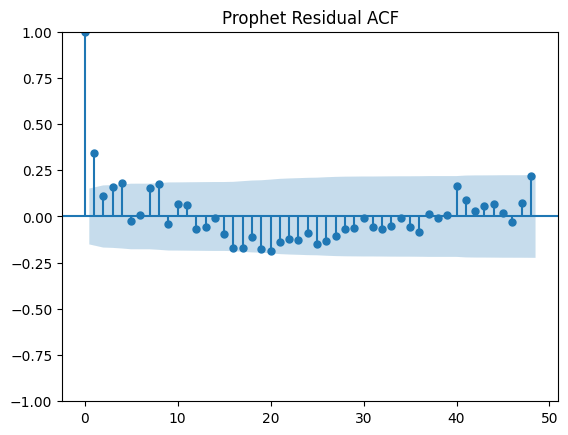

In [47]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(sarima_resid, lags=48)
plt.title("SARIMA Residual ACF")
plt.show()

plot_acf(prophet_resid, lags=48)
plt.title("Prophet Residual ACF")
plt.show()


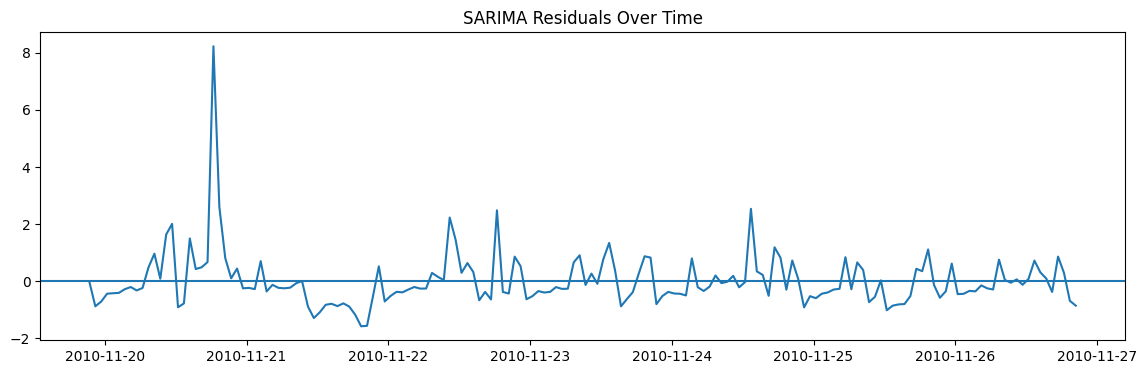

In [48]:
plt.figure(figsize=(14,4))
plt.plot(test.index, sarima_resid)
plt.axhline(0)
plt.title("SARIMA Residuals Over Time")
plt.show()


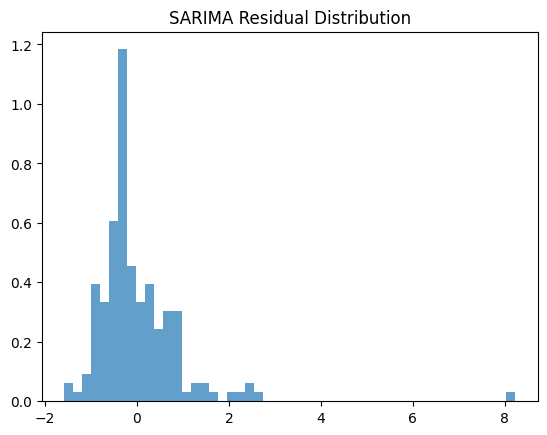

In [49]:
plt.hist(sarima_resid, bins=50, alpha=0.7, density=True)
plt.title("SARIMA Residual Distribution")
plt.show()


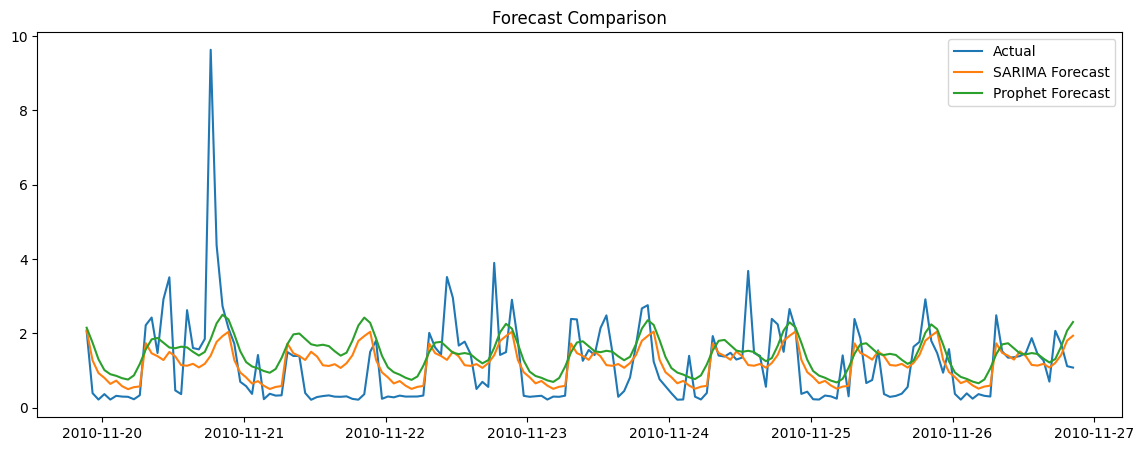

In [50]:
plt.figure(figsize=(14,5))
plt.plot(test.index, y_true, label='Actual')
plt.plot(test.index, y_pred_sarima, label='SARIMA Forecast')
plt.plot(test.index, y_pred_prophet, label='Prophet Forecast')
plt.legend()
plt.title("Forecast Comparison")
plt.show()


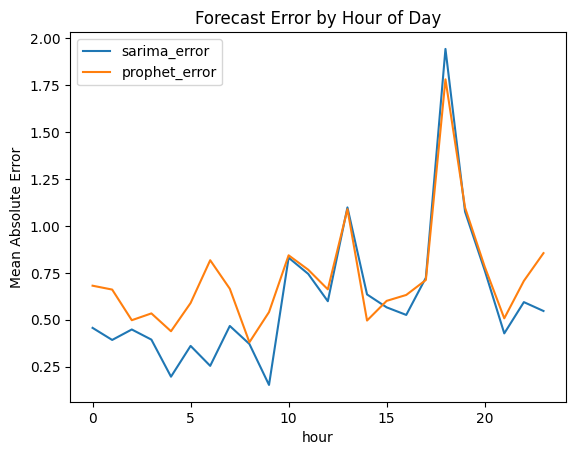

In [51]:
error_df = pd.DataFrame({
    'hour': test.index.hour,
    'sarima_error': abs(sarima_resid),
    'prophet_error': abs(prophet_resid)
})

error_df.groupby('hour').mean().plot()
plt.ylabel("Mean Absolute Error")
plt.title("Forecast Error by Hour of Day")
plt.show()


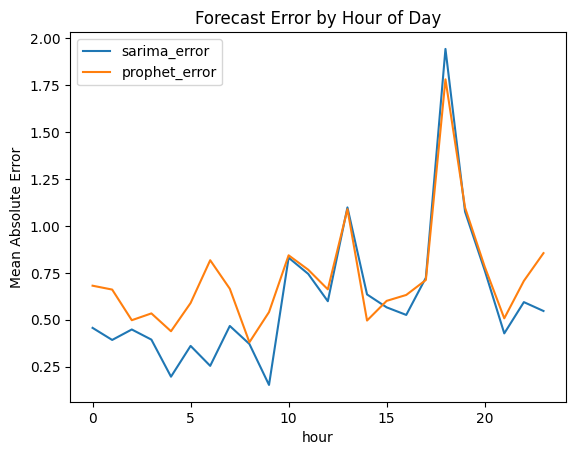

In [52]:
error_df = pd.DataFrame({
    'hour': test.index.hour,
    'sarima_error': abs(sarima_resid),
    'prophet_error': abs(prophet_resid)
})

error_df.groupby('hour').mean().plot()
plt.ylabel("Mean Absolute Error")
plt.title("Forecast Error by Hour of Day")
plt.show()


In [54]:
print(sarima_clean.aic)
print(sarima_clean.bic)



76694.88196756461
76737.11029998442
